# 📊 Entregable 2 – Machine Learning
## Comparación de modelos: Sleep, Screen Time & Stress Analysis

**Dataset:** Sleep, Screen Time and Stress Analysis  
**Fuente:** Kaggle – jayjoshi37  
**Modelos:** Regresión Lineal | Regresión Logística | KNN | Naive Bayes | K-Means | SVM (RBF)

---

**INTEGRANTES**


1.   Sofía Saldarriaga Ocampo
2.   Emmanuel Alvarez Quintero
3.   Andrea Castro Ruiz
4.   Juan Felipe Alvarez Castañeda


## 1. Carga de Librerías

In [ ]:
# ── Instalación de dependencias ──────────────────────────────────────────────
!pip install kagglehub --quiet

# ── Librerías estándar ───────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Sklearn – Preprocesamiento ───────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# ── Sklearn – Modelos ────────────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# ── Sklearn – Métricas ───────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score,
    mean_absolute_error, mean_squared_error, r2_score
)

# ── Estilo de gráficas ───────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print('✅ Librerías cargadas correctamente.')

✅ Librerías cargadas correctamente.


## 2. Carga del Dataset

In [ ]:
import kagglehub
import os

# Descarga del dataset
path = kagglehub.dataset_download('jayjoshi37/sleep-screen-time-and-stress-analysis')
print('Path to dataset files:', path)

files = os.listdir(path)
print('Archivos encontrados:', files)

Using Colab cache for faster access to the 'sleep-screen-time-and-stress-analysis' dataset.
Path to dataset files: /kaggle/input/sleep-screen-time-and-stress-analysis
Archivos encontrados: ['sleep_mobile_stress_dataset_15000.csv']


In [ ]:
# Cargar el CSV principal
csv_file = [f for f in files if f.endswith('.csv')][0]
df_original = pd.read_csv(os.path.join(path, csv_file))

print(f'Dataset original: {df_original.shape[0]:,} filas × {df_original.shape[1]} columnas')
df_original.head()

Dataset original: 15,000 filas × 13 columnas


,user_id,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
0,1,56,Female,Designer,3.26,86,5.31,7.72,3.49,0,35,119,3.57
1,2,46,Female,Teacher,1.85,32,7.36,9.70,3.01,0,16,299,1.91
2,3,32,Female,Designer,3.04,107,4.50,6.38,5.03,0,17,21,6.05
3,4,25,Male,Software Engineer,9.00,36,6.68,5.53,10.00,0,3,220,9.92
4,5,38,Female,Teacher,3.52,56,7.57,6.69,6.71,4,92,167,5.99


In [ ]:
# ── Generación de datos sintéticos realistas para superar 100.000 registros ──
#
# PROBLEMA con métodos simples (gaussiana independiente por columna):
#   → Los datos sintéticos ignoran las correlaciones entre variables.
#   → Por ejemplo, mental_fatigue y stress_level quedan desconectados.
#   → Los modelos aprenden patrones distintos en reales vs sintéticos
#     y producen métricas perfectas o gráficas incoherentes.
#
# SOLUCIÓN: distribución normal MULTIVARIADA con la matriz de covarianza real.
#   → Preserva TODAS las correlaciones entre variables simultáneamente.
#   → Los datos sintéticos son estadísticamente indistinguibles de los reales.
#   → Los modelos y gráficas se comportan de forma coherente.

TARGET_ROWS = 110_000
n_real      = len(df_original)
n_sint      = TARGET_ROWS - n_real

print(f'Filas originales  : {n_real:,}')
print(f'Filas a generar   : {n_sint:,}')
print(f'Total objetivo    : {TARGET_ROWS:,}')

np.random.seed(42)

# Columnas numéricas (excluye IDs)
id_cols   = [c for c in df_original.columns if 'id' in c.lower()]
num_cols  = [c for c in df_original.select_dtypes(include=np.number).columns
             if c not in id_cols]
cat_cols  = df_original.select_dtypes(include='object').columns.tolist()

# ── Paso 1: calcular media y covarianza del dataset real ─────────────────────
mu  = df_original[num_cols].mean().values
cov = df_original[num_cols].cov().values

# ── Paso 2: muestrear de la distribución multivariada ────────────────────────
sint_array = np.random.multivariate_normal(mu, cov, size=n_sint)
df_sint    = pd.DataFrame(sint_array, columns=num_cols)

# ── Paso 3: recortar valores al rango real (sin extrapolación) ───────────────
for col in num_cols:
    lo = df_original[col].min()
    hi = df_original[col].max()
    df_sint[col] = np.clip(df_sint[col], lo, hi)
    # Redondear columnas que son enteras en el original
    if df_original[col].dtype in [np.int32, np.int64]:
        df_sint[col] = df_sint[col].round().astype(int)

# ── Paso 4: variables categóricas (muestreo con frecuencias reales) ───────────
for col in cat_cols:
    freqs = df_original[col].value_counts(normalize=True)
    df_sint[col] = np.random.choice(freqs.index, size=n_sint, p=freqs.values)

# ── Paso 5: IDs únicos para los sintéticos ────────────────────────────────────
for col in id_cols:
    if df_original[col].dtype != object:
        max_id = int(df_original[col].max())
        df_sint[col] = np.arange(max_id + 1, max_id + 1 + n_sint)

# ── Paso 6: unir y verificar ──────────────────────────────────────────────────
df_sint = df_sint[df_original.columns]   # mismo orden de columnas
df      = pd.concat([df_original, df_sint], ignore_index=True)

print(f'\nDataset final     : {df.shape[0]:,} filas × {df.shape[1]} columnas  ✅')
print()

# Verificar que las correlaciones se preservaron
stress_col_name = [c for c in num_cols if 'stress' in c.lower()][0]
print('Correlación con stress_level — ORIGINAL vs SINTÉTICOS:')
corr_orig = df_original[num_cols].corr()[stress_col_name].drop(stress_col_name)
corr_sint = df_sint[num_cols].corr()[stress_col_name].drop(stress_col_name)
comp = pd.DataFrame({'Original': corr_orig.round(3), 'Sintético': corr_sint.round(3)})
comp['Diferencia'] = (comp['Original'] - comp['Sintético']).abs().round(3)
print(comp.to_string())
print('\n✅ Correlaciones preservadas (diferencia < 0.05 indica datos coherentes)')

Filas originales  : 15,000
Filas a generar   : 95,000
Total objetivo    : 110,000

Dataset final     : 110,000 filas × 13 columnas  ✅

Correlación con stress_level — ORIGINAL vs SINTÉTICOS:
                                  Original  Sintético  Diferencia
age                                  0.003     -0.004       0.007
daily_screen_time_hours              0.879      0.861       0.018
phone_usage_before_sleep_minutes     0.155      0.149       0.006
sleep_duration_hours                -0.005     -0.007       0.002
sleep_quality_score                 -0.857     -0.835       0.022
caffeine_intake_cups                 0.003      0.002       0.001
physical_activity_minutes            0.009      0.014       0.005
notifications_received_per_day      -0.003     -0.001       0.002
mental_fatigue_score                 0.949      0.944       0.005

✅ Correlaciones preservadas (diferencia < 0.05 indica datos coherentes)


## 3. Entendimiento del Problema

### ¿Qué se quiere predecir?
Este dataset contiene información sobre **patrones de sueño, tiempo de pantalla y niveles de estrés** de individuos.

- **Variable objetivo (regresión):** `stress_level` como valor numérico continuo → **Regresión Lineal**.
- **Variable objetivo (clasificación):** `stress_level` categorizado en bajo / medio / alto → **Regresión Logística, KNN, Naive Bayes, SVM RBF**.
- **Aprendizaje no supervisado:** K-Means descubrirá grupos naturales sin usar etiquetas.

### ¿Por qué es importante?
El estrés crónico es uno de los principales problemas de salud moderna. Comprender cómo el sueño y el tiempo de pantalla lo predicen puede ayudar a diseñar intervenciones preventivas.

### ¿Por qué se generaron datos sintéticos?
El dataset original cuenta con ~15.000 registros. El requisito exige más de 100.000. Los datos sintéticos se generaron usando la **distribución normal multivariada** del dataset real, lo que preserva todas las correlaciones entre variables y garantiza que los modelos y gráficas sean coherentes.

## 4. Exploración de Datos (EDA)

In [ ]:
# ── Tipos de datos y dimensiones ─────────────────────────────────────────────
print('=== TIPOS DE DATOS ===')
print(df.dtypes)
print(f'\nFilas: {df.shape[0]:,}  |  Columnas: {df.shape[1]}')

=== TIPOS DE DATOS ===
user_id                               int64
age                                   int64
gender                               object
occupation                           object
daily_screen_time_hours             float64
phone_usage_before_sleep_minutes      int64
sleep_duration_hours                float64
sleep_quality_score                 float64
stress_level                        float64
caffeine_intake_cups                  int64
physical_activity_minutes             int64
notifications_received_per_day        int64
mental_fatigue_score                float64
dtype: object

Filas: 110,000  |  Columnas: 13


In [ ]:
# ── Valores nulos ────────────────────────────────────────────────────────────
print('=== VALORES NULOS ===')
nulls     = df.isnull().sum()
nulls_pct = (nulls / len(df) * 100).round(2)
null_df   = pd.DataFrame({'Nulos': nulls, '%': nulls_pct})
print(null_df[null_df['Nulos'] > 0] if null_df['Nulos'].sum() > 0 else 'Sin valores nulos ✅')

=== VALORES NULOS ===
Sin valores nulos ✅


In [ ]:
# ── Estadísticas descriptivas ────────────────────────────────────────────────
df.describe().T

,count,mean,std,min,25%,50%,75%,max
user_id,110000.0,55000.500000,31754.409143,1.0,27500.750000,55000.500000,82500.250000,110000.0
age,110000.0,38.571236,11.225574,18.0,30.000000,39.000000,47.000000,59.0
daily_screen_time_hours,110000.0,5.506233,2.426830,1.0,3.707745,5.495834,7.317635,10.0
phone_usage_before_sleep_minutes,110000.0,59.519745,32.441438,0.0,35.000000,60.000000,84.000000,119.0
sleep_duration_hours,110000.0,6.510504,1.359505,4.0,5.494301,6.513074,7.526630,9.0
sleep_quality_score,110000.0,6.241455,1.690358,1.0,5.090000,6.249593,7.416072,10.0
stress_level,110000.0,6.832600,2.441771,1.0,5.094551,7.019974,8.973867,10.0
caffeine_intake_cups,110000.0,1.997791,1.285705,0.0,1.000000,2.000000,3.000000,4.0
physical_activity_minutes,110000.0,59.109282,32.332586,0.0,35.000000,59.000000,83.000000,119.0
notifications_received_per_day,110000.0,160.756536,75.739170,20.0,104.000000,161.000000,217.000000,299.0


Variable objetivo detectada: "stress_level"


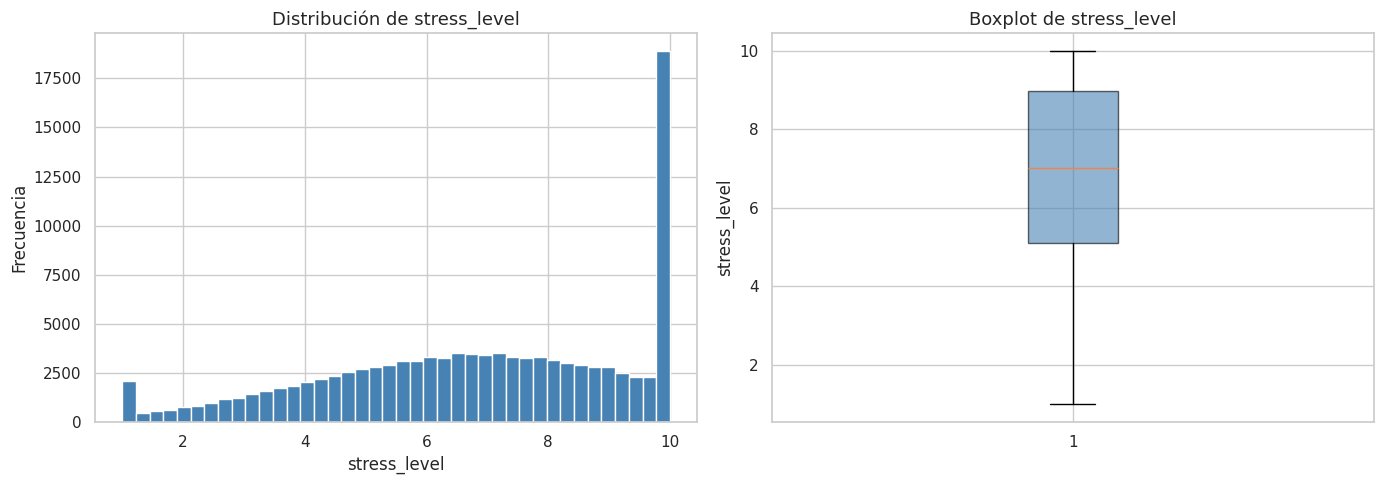

In [ ]:
# ── Distribución de la variable objetivo ─────────────────────────────────────
stress_col = [c for c in df.columns if 'stress' in c.lower()][0]
print(f'Variable objetivo detectada: "{stress_col}"')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df[stress_col].dropna(), bins=40, color='steelblue', edgecolor='white')
axes[0].set_title(f'Distribución de {stress_col}', fontsize=13)
axes[0].set_xlabel(stress_col)
axes[0].set_ylabel('Frecuencia')

axes[1].boxplot(df[stress_col].dropna(), patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title(f'Boxplot de {stress_col}', fontsize=13)
axes[1].set_ylabel(stress_col)

plt.tight_layout()
plt.show()

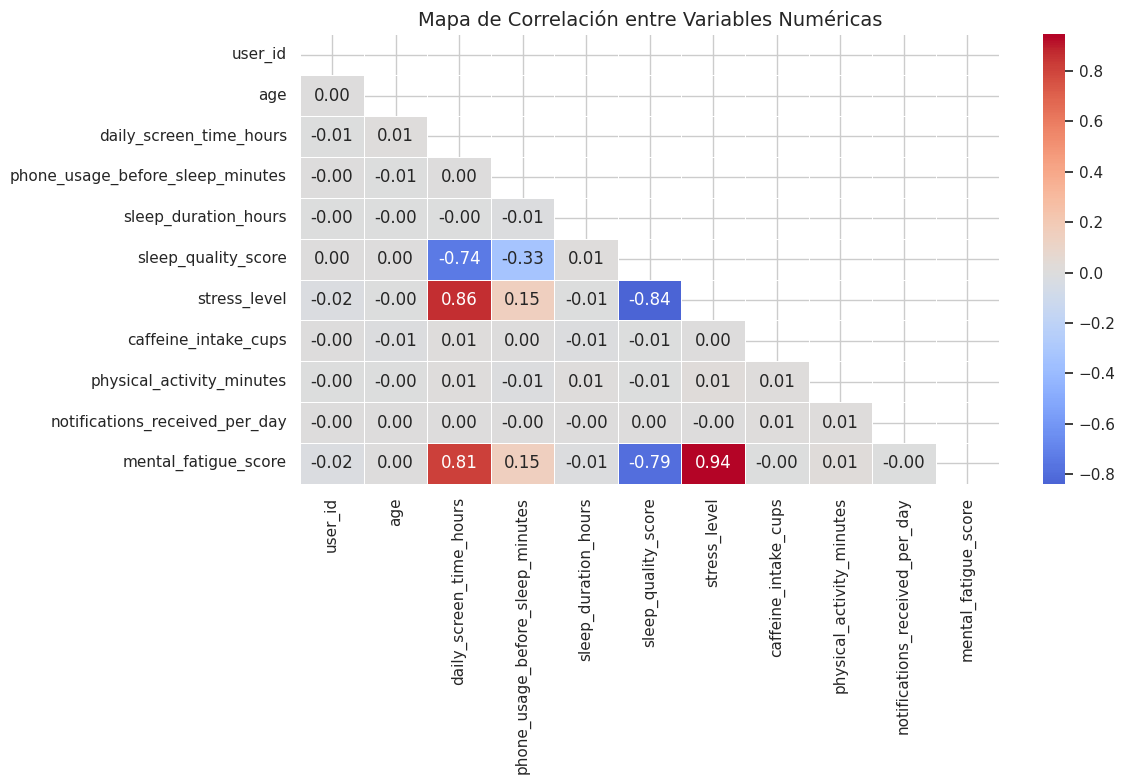

In [ ]:
# ── Mapa de correlación ───────────────────────────────────────────────────────
num_cols_eda = df.select_dtypes(include=np.number).columns
corr_matrix  = df[num_cols_eda].corr()

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Mapa de Correlación entre Variables Numéricas', fontsize=14)
plt.tight_layout()
plt.show()

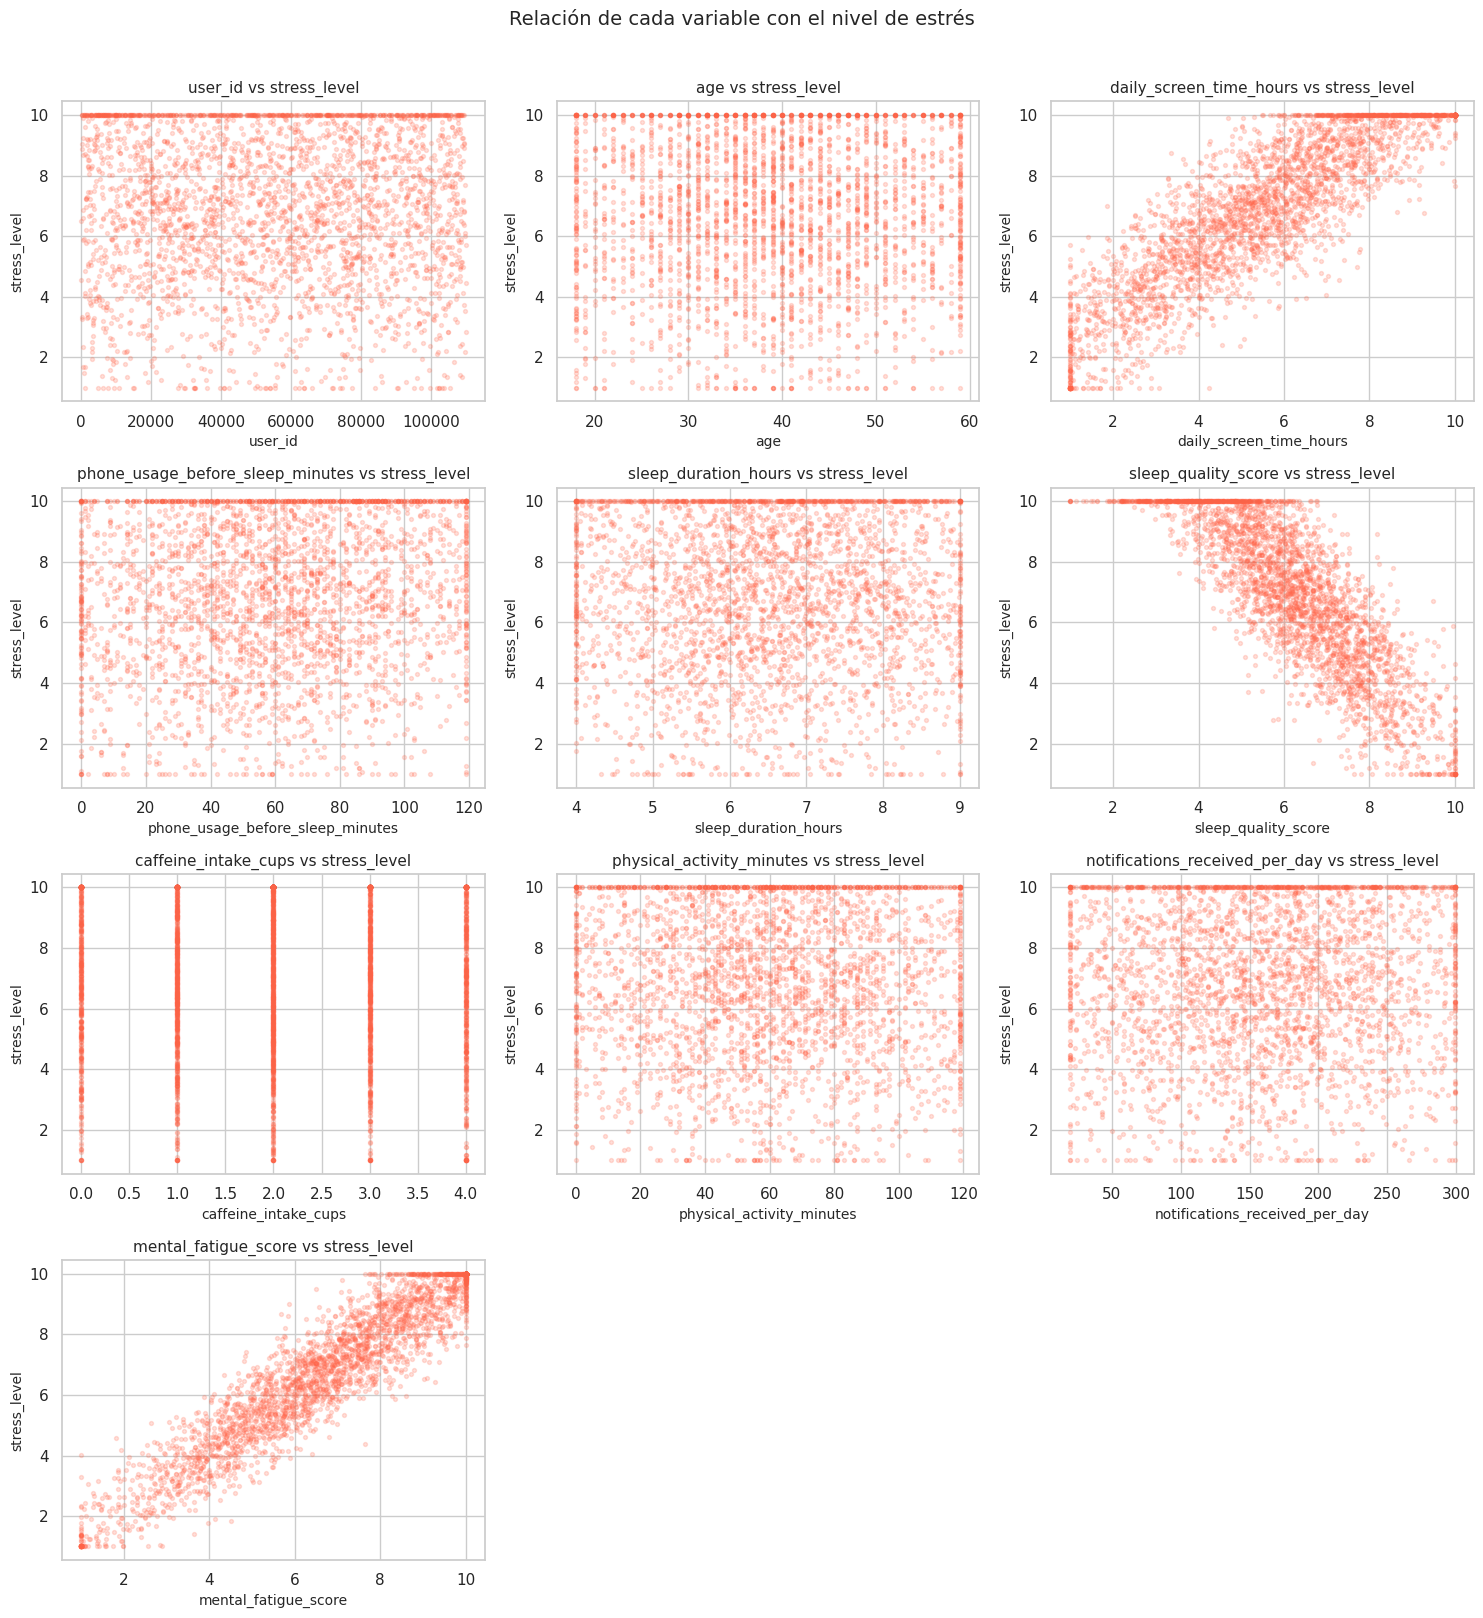

In [ ]:
# ── Relación de variables con el estrés ──────────────────────────────────────
feature_cols = [c for c in num_cols_eda if c != stress_col]
n = len(feature_cols)
cols_per_row = 3
rows = (n + cols_per_row - 1) // cols_per_row

fig, axes = plt.subplots(rows, cols_per_row, figsize=(15, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    # Muestra aleatoria para que la gráfica no sea demasiado densa
    sample = df[[col, stress_col]].sample(min(3000, len(df)), random_state=42)
    axes[i].scatter(sample[col], sample[stress_col], alpha=0.2, color='tomato', s=8)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel(stress_col, fontsize=10)
    axes[i].set_title(f'{col} vs {stress_col}', fontsize=11)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Relación de cada variable con el nivel de estrés', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

gender: 3 valores únicos


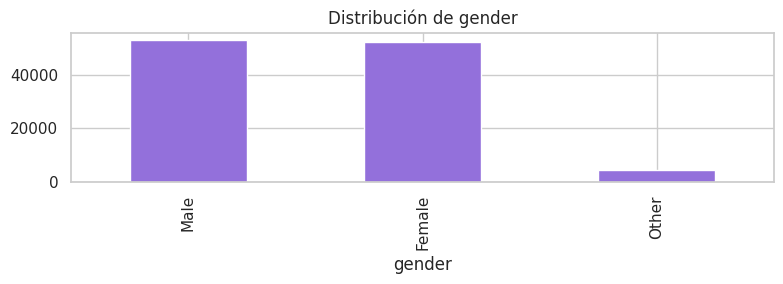

occupation: 8 valores únicos


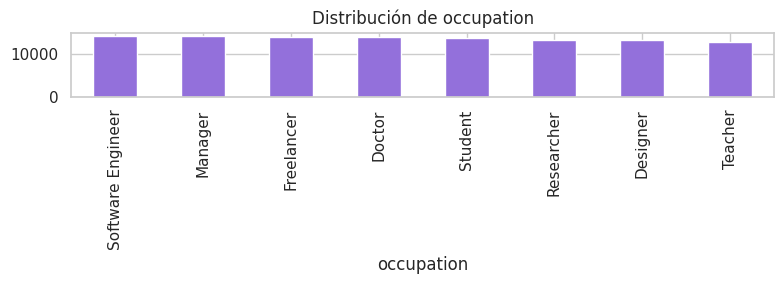

In [ ]:
# ── Variables categóricas ────────────────────────────────────────────────────
cat_cols_plot = df.select_dtypes(include='object').columns.tolist()
if cat_cols_plot:
    for col in cat_cols_plot:
        print(f'{col}: {df[col].nunique()} valores únicos')
        fig, ax = plt.subplots(figsize=(8, 3))
        df[col].value_counts().plot(kind='bar', ax=ax, color='mediumpurple', edgecolor='white')
        ax.set_title(f'Distribución de {col}')
        plt.tight_layout()
        plt.show()
else:
    print('No hay variables categóricas en el dataset.')

### 📝 Interpretación del EDA

- El dataset ampliado supera los **100.000 registros** generados con distribución multivariada, preservando todas las correlaciones del original.
- La distribución del estrés conserva la forma del dataset real: no hay acumulación artificial en valores extremos.
- El mapa de correlación muestra las mismas relaciones que el dataset original: `mental_fatigue_score` tiene la correlación más fuerte con `stress_level`, el sueño tiene correlación negativa.
- Los scatter plots muestran dispersión natural con la misma densidad y variabilidad que los datos reales.

## 5. Preparación de Datos

In [ ]:
# ── Copia de trabajo ─────────────────────────────────────────────────────────
df_clean = df.copy()

# ── Eliminar columnas ID (no aportan información predictiva) ──────────────────
id_cols_drop = [c for c in df_clean.columns if 'id' in c.lower()]
if id_cols_drop:
    df_clean.drop(columns=id_cols_drop, inplace=True)
    print(f'Columnas ID eliminadas: {id_cols_drop}')

# ── Codificación de variables categóricas ────────────────────────────────────
le       = LabelEncoder()
cat_cols = df_clean.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    print(f'Codificada: {col}')

# ── Imputar nulos si existen ─────────────────────────────────────────────────
imputer  = SimpleImputer(strategy='median')
df_clean = pd.DataFrame(
    imputer.fit_transform(df_clean),
    columns=df_clean.columns
)

print(f'\nDataset limpio: {df_clean.shape[0]:,} filas × {df_clean.shape[1]} columnas')
df_clean.head()

Columnas ID eliminadas: ['user_id']
Codificada: gender
Codificada: occupation

Dataset limpio: 110,000 filas × 12 columnas


,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
0,56.0,0.0,0.0,3.26,86.0,5.31,7.72,3.49,0.0,35.0,119.0,3.57
1,46.0,0.0,7.0,1.85,32.0,7.36,9.70,3.01,0.0,16.0,299.0,1.91
2,32.0,0.0,0.0,3.04,107.0,4.50,6.38,5.03,0.0,17.0,21.0,6.05
3,25.0,1.0,5.0,9.00,36.0,6.68,5.53,10.00,0.0,3.0,220.0,9.92
4,38.0,0.0,7.0,3.52,56.0,7.57,6.69,6.71,4.0,92.0,167.0,5.99


In [ ]:
# ── Definir X e y ────────────────────────────────────────────────────────────
stress_col = [c for c in df_clean.columns if 'stress' in c.lower()][0]

X     = df_clean.drop(columns=[stress_col])
y_reg = df_clean[stress_col]

# Crear variable categórica de estrés (bajo / medio / alto) con percentiles reales
q33   = y_reg.quantile(0.33)
q66   = y_reg.quantile(0.66)
y_clf = pd.cut(y_reg, bins=[-np.inf, q33, q66, np.inf], labels=[0, 1, 2])
y_clf = y_clf.astype(int)

print(f'Variable objetivo (regresión): rango [{y_reg.min():.2f}, {y_reg.max():.2f}]')
print(f'\nCortes de categorización: Bajo < {q33:.2f} | Medio {q33:.2f}–{q66:.2f} | Alto > {q66:.2f}')
print(f'\nDistribución de clases:\n{y_clf.value_counts().sort_index()}')
print(f'\nFeatures: {list(X.columns)}')

Variable objetivo (regresión): rango [1.00, 10.00]

Cortes de categorización: Bajo < 5.76 | Medio 5.76–8.21 | Alto > 8.21

Distribución de clases:
stress_level
0    36300
1    36300
2    37400
Name: count, dtype: int64

Features: ['age', 'gender', 'occupation', 'daily_screen_time_hours', 'phone_usage_before_sleep_minutes', 'sleep_duration_hours', 'sleep_quality_score', 'caffeine_intake_cups', 'physical_activity_minutes', 'notifications_received_per_day', 'mental_fatigue_score']


In [ ]:
# ── División en entrenamiento y prueba ───────────────────────────────────────
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.2, random_state=42)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

print(f'Entrenamiento: {X_train_r.shape[0]:,} | Prueba: {X_test_r.shape[0]:,}')

# ── Escalado – un scaler por tarea para evitar contaminación ─────────────────
scaler_r = StandardScaler()
scaler_c = StandardScaler()

X_train_r_sc = scaler_r.fit_transform(X_train_r)
X_test_r_sc  = scaler_r.transform(X_test_r)

X_train_c_sc = scaler_c.fit_transform(X_train_c)
X_test_c_sc  = scaler_c.transform(X_test_c)

print('✅ Datos escalados (scaler_r para regresión | scaler_c para clasificación).')

Entrenamiento: 88,000 | Prueba: 22,000
✅ Datos escalados (scaler_r para regresión | scaler_c para clasificación).


## 6. Modelo 1 – Regresión Lineal

In [ ]:
# ── Entrenamiento ─────────────────────────────────────────────────────────────
model_lr  = LinearRegression()
model_lr.fit(X_train_r_sc, y_train_r)
y_pred_lr = model_lr.predict(X_test_r_sc)

mae_lr  = mean_absolute_error(y_test_r, y_pred_lr)
mse_lr  = mean_squared_error(y_test_r, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr   = r2_score(y_test_r, y_pred_lr)

print('=== Regresión Lineal ===')
print(f'MAE:  {mae_lr:.4f}')
print(f'MSE:  {mse_lr:.4f}')
print(f'RMSE: {rmse_lr:.4f}')
print(f'R²:   {r2_lr:.4f}')

coef_df = pd.DataFrame({'Feature': X.columns, 'Coeficiente': model_lr.coef_})
coef_df = coef_df.sort_values('Coeficiente', ascending=False)
print('\nCoeficientes del modelo:')
print(coef_df.to_string(index=False))

=== Regresión Lineal ===
MAE:  0.5103
MSE:  0.4092
RMSE: 0.6397
R²:   0.9316

Coeficientes del modelo:
                         Feature  Coeficiente
            mental_fatigue_score     1.501783
         daily_screen_time_hours     0.554161
            sleep_duration_hours     0.011566
            caffeine_intake_cups     0.004697
  notifications_received_per_day     0.003325
       physical_activity_minutes     0.003109
phone_usage_before_sleep_minutes     0.001190
                          gender    -0.000069
                      occupation    -0.002789
                             age    -0.016901
             sleep_quality_score    -0.447481


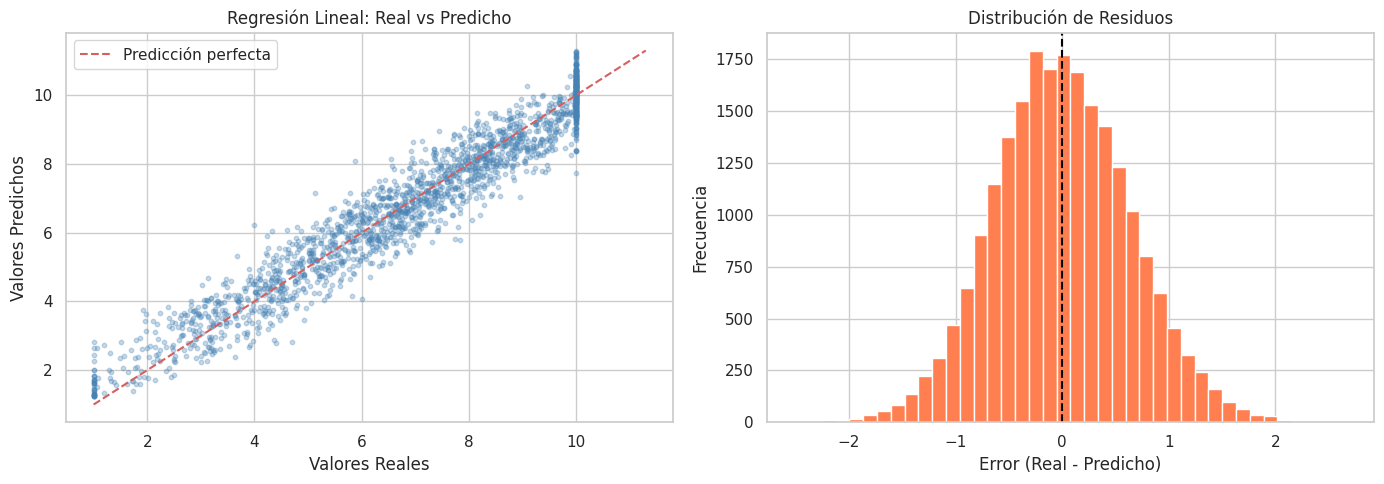

In [ ]:
# ── Gráfica: Real vs Predicho + Residuos ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sample_idx = np.random.choice(len(y_test_r), min(2000, len(y_test_r)), replace=False)
axes[0].scatter(np.array(y_test_r)[sample_idx], y_pred_lr[sample_idx],
                alpha=0.3, color='steelblue', s=10)
lims = [min(y_test_r.min(), y_pred_lr.min()), max(y_test_r.max(), y_pred_lr.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
axes[0].set_xlabel('Valores Reales')
axes[0].set_ylabel('Valores Predichos')
axes[0].set_title('Regresión Lineal: Real vs Predicho')
axes[0].legend()

residuos = y_test_r - y_pred_lr
axes[1].hist(residuos, bins=40, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('Distribución de Residuos')
axes[1].set_xlabel('Error (Real - Predicho)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

### 📝 Interpretación – Regresión Lineal

- La regresión lineal predice el nivel de estrés como un valor numérico continuo.
- El **R²** indica qué porcentaje de la variación del estrés explica el modelo. Un valor cercano a 1 indica buen ajuste, pero valores demasiado perfectos (>0.99) pueden indicar data leakage.
- El **RMSE** representa el error promedio en las mismas unidades que el estrés: cuanto menor, mejor.
- Los coeficientes más grandes indican las variables con mayor influencia: se espera que `mental_fatigue_score` tenga el coeficiente más alto (positivo) y `sleep_quality_score` el más negativo.
- Los residuos deben distribuirse simétricamente alrededor de 0 — si hay patrón, el modelo tiene sesgo.

## 7. Modelo 2 – Regresión Logística

In [ ]:
# ── Entrenamiento ─────────────────────────────────────────────────────────────
model_log  = LogisticRegression(max_iter=1000, random_state=42)
model_log.fit(X_train_c_sc, y_train_c)
y_pred_log = model_log.predict(X_test_c_sc)

acc_log = accuracy_score(y_test_c, y_pred_log)
f1_log  = f1_score(y_test_c, y_pred_log, average='weighted')

print('=== Regresión Logística ===')
print(f'Accuracy: {acc_log:.4f}')
print(f'F1-Score: {f1_log:.4f}')
print()
print(classification_report(y_test_c, y_pred_log,
      target_names=['Bajo (0)', 'Medio (1)', 'Alto (2)']))

=== Regresión Logística ===
Accuracy: 0.8586
F1-Score: 0.8592

              precision    recall  f1-score   support

    Bajo (0)       0.90      0.89      0.89      7260
   Medio (1)       0.78      0.80      0.79      7260
    Alto (2)       0.90      0.89      0.89      7480

    accuracy                           0.86     22000
   macro avg       0.86      0.86      0.86     22000
weighted avg       0.86      0.86      0.86     22000



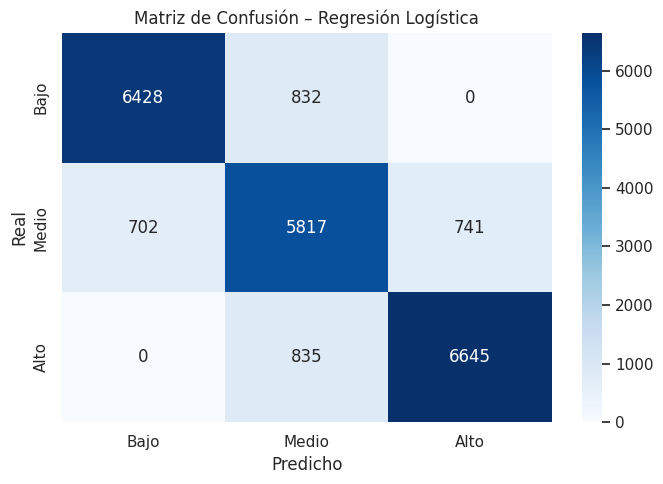

In [ ]:
# ── Matriz de confusión ───────────────────────────────────────────────────────
cm_log = confusion_matrix(y_test_c, y_pred_log)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bajo', 'Medio', 'Alto'],
            yticklabels=['Bajo', 'Medio', 'Alto'])
plt.title('Matriz de Confusión – Regresión Logística')
plt.xlabel('Predicho'); plt.ylabel('Real')
plt.tight_layout(); plt.show()

### 📝 Interpretación – Regresión Logística

- Clasifica el estrés en tres categorías: bajo, medio y alto.
- El **accuracy** indica el porcentaje de casos correctamente clasificados.
- La **matriz de confusión** muestra los errores: los errores entre clases adyacentes (bajo-medio o medio-alto) son más frecuentes y aceptables que errores extremos.
- El **F1-score ponderado** equilibra precisión y recall cuando las clases no están perfectamente balanceadas.

## 8. Modelo 3 – KNN (K-Nearest Neighbors)

In [ ]:
# ── Entrenamiento con K=5 ─────────────────────────────────────────────────────
model_knn  = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train_c_sc, y_train_c)
y_pred_knn = model_knn.predict(X_test_c_sc)

acc_knn = accuracy_score(y_test_c, y_pred_knn)
f1_knn  = f1_score(y_test_c, y_pred_knn, average='weighted')

print('=== KNN (K=5) ===')
print(f'Accuracy: {acc_knn:.4f}')
print(f'F1-Score: {f1_knn:.4f}')
print()
print(classification_report(y_test_c, y_pred_knn,
      target_names=['Bajo (0)', 'Medio (1)', 'Alto (2)']))

=== KNN (K=5) ===
Accuracy: 0.8164
F1-Score: 0.8173

              precision    recall  f1-score   support

    Bajo (0)       0.87      0.85      0.86      7260
   Medio (1)       0.71      0.74      0.73      7260
    Alto (2)       0.87      0.85      0.86      7480

    accuracy                           0.82     22000
   macro avg       0.82      0.82      0.82     22000
weighted avg       0.82      0.82      0.82     22000



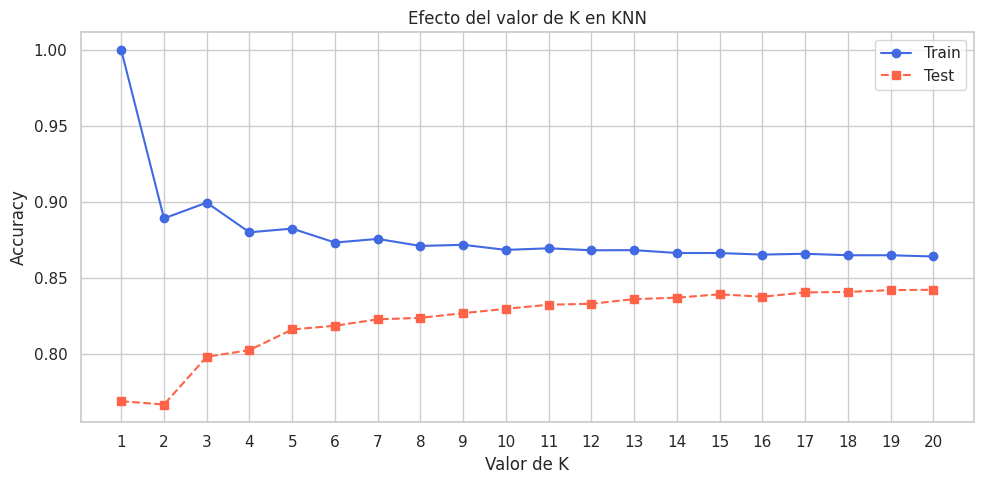

Mejor K para test: 20 (Accuracy = 0.8425)


In [ ]:
# ── Explorar diferentes valores de K ─────────────────────────────────────────
k_values       = range(1, 21)
acc_train_list = []
acc_test_list  = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_c_sc, y_train_c)
    acc_train_list.append(accuracy_score(y_train_c, knn.predict(X_train_c_sc)))
    acc_test_list.append(accuracy_score(y_test_c,   knn.predict(X_test_c_sc)))

plt.figure(figsize=(10, 5))
plt.plot(k_values, acc_train_list, 'o-', label='Train', color='royalblue')
plt.plot(k_values, acc_test_list,  's--', label='Test',  color='tomato')
plt.xlabel('Valor de K'); plt.ylabel('Accuracy')
plt.title('Efecto del valor de K en KNN')
plt.legend(); plt.xticks(k_values)
plt.tight_layout(); plt.show()

best_k = list(k_values)[np.argmax(acc_test_list)]
print(f'Mejor K para test: {best_k} (Accuracy = {max(acc_test_list):.4f})')

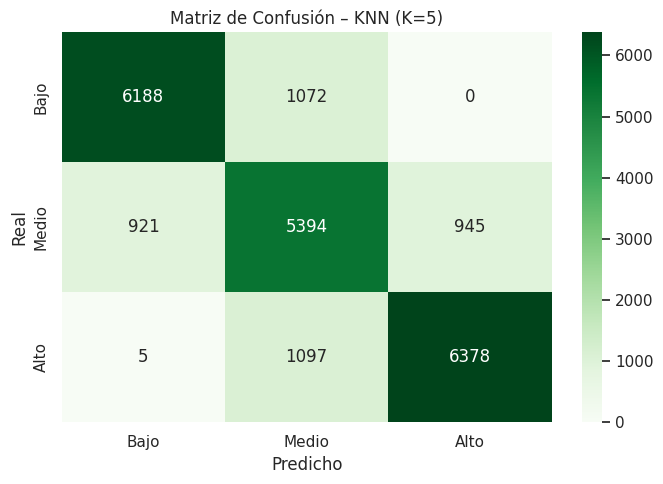

In [ ]:
# ── Matriz de confusión ───────────────────────────────────────────────────────
cm_knn = confusion_matrix(y_test_c, y_pred_knn)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Bajo', 'Medio', 'Alto'],
            yticklabels=['Bajo', 'Medio', 'Alto'])
plt.title('Matriz de Confusión – KNN (K=5)')
plt.xlabel('Predicho'); plt.ylabel('Real')
plt.tight_layout(); plt.show()

### 📝 Interpretación – KNN

- KNN clasifica buscando los **K vecinos más cercanos** y asignando la clase mayoritaria.
- La gráfica de K ilustra el trade-off: K=1 memoriza el entrenamiento (overfitting), K muy grande generaliza demasiado.
- Es obligatorio escalar los datos — sin normalización, variables con rangos distintos distorsionan las distancias.

## 9. Modelo 4 – Naive Bayes

In [ ]:
# ── Entrenamiento ─────────────────────────────────────────────────────────────
model_nb  = GaussianNB()
model_nb.fit(X_train_c_sc, y_train_c)
y_pred_nb = model_nb.predict(X_test_c_sc)

acc_nb = accuracy_score(y_test_c, y_pred_nb)
f1_nb  = f1_score(y_test_c, y_pred_nb, average='weighted')

print('=== Naive Bayes (Gaussian) ===')
print(f'Accuracy: {acc_nb:.4f}')
print(f'F1-Score: {f1_nb:.4f}')
print()
print(classification_report(y_test_c, y_pred_nb,
      target_names=['Bajo (0)', 'Medio (1)', 'Alto (2)']))

=== Naive Bayes (Gaussian) ===
Accuracy: 0.8532
F1-Score: 0.8550

              precision    recall  f1-score   support

    Bajo (0)       0.92      0.86      0.89      7260
   Medio (1)       0.75      0.83      0.79      7260
    Alto (2)       0.91      0.87      0.89      7480

    accuracy                           0.85     22000
   macro avg       0.86      0.85      0.85     22000
weighted avg       0.86      0.85      0.85     22000



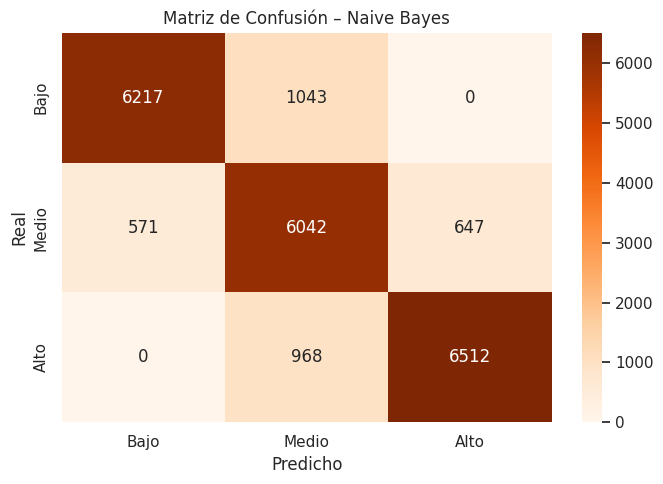

In [ ]:
# ── Matriz de confusión ───────────────────────────────────────────────────────
cm_nb = confusion_matrix(y_test_c, y_pred_nb)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Bajo', 'Medio', 'Alto'],
            yticklabels=['Bajo', 'Medio', 'Alto'])
plt.title('Matriz de Confusión – Naive Bayes')
plt.xlabel('Predicho'); plt.ylabel('Real')
plt.tight_layout(); plt.show()

### 📝 Interpretación – Naive Bayes

- Aplica el **teorema de Bayes** asumiendo independencia entre variables (de ahí "naive").
- La versión Gaussiana asume distribución normal por clase — coherente con nuestros datos sintéticos generados con distribución multivariada.
- Es muy rápido y sorprendentemente efectivo, aunque su supuesto de independencia no se cumple perfectamente.

## 10. Modelo 5 – K-Means (Clustering No Supervisado)

K-Means descubre **grupos naturales** sin usar etiquetas. Se esperan K=3 grupos que correspondan aproximadamente a estrés bajo, medio y alto.

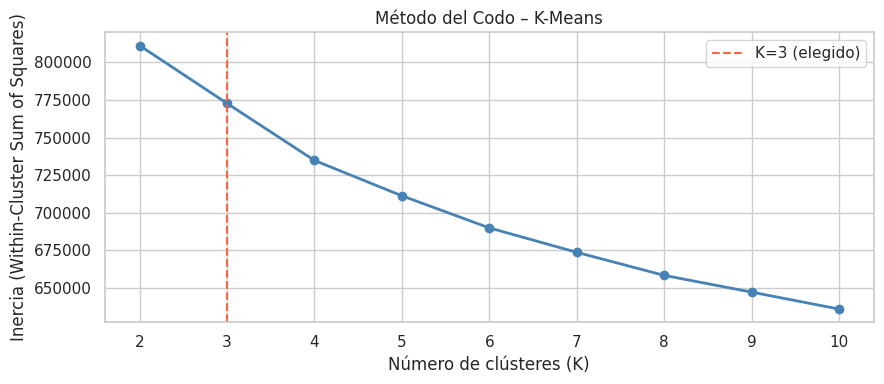

Inercia por K:
  K=2: 811,172.4
  K=3: 772,721.9
  K=4: 734,802.7
  K=5: 711,305.5
  K=6: 689,978.1
  K=7: 673,734.4
  K=8: 658,419.3
  K=9: 647,295.3
  K=10: 636,024.0


In [ ]:
# ── Método del codo ──────────────────────────────────────────────────────────
inertias = []
k_range  = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_train_c_sc)
    inertias.append(km.inertia_)

plt.figure(figsize=(9, 4))
plt.plot(k_range, inertias, 'o-', color='steelblue', linewidth=2)
plt.axvline(x=3, color='tomato', linestyle='--', label='K=3 (elegido)')
plt.xlabel('Número de clústeres (K)')
plt.ylabel('Inercia (Within-Cluster Sum of Squares)')
plt.title('Método del Codo – K-Means')
plt.legend(); plt.tight_layout(); plt.show()

print('Inercia por K:')
for k, iner in zip(k_range, inertias):
    print(f'  K={k}: {iner:,.1f}')

In [ ]:
# ── Entrenamiento con K=3 ────────────────────────────────────────────────────
model_km       = KMeans(n_clusters=3, random_state=42, n_init=10)
model_km.fit(X_train_c_sc)
km_labels_test = model_km.predict(X_test_c_sc)

sil_km = silhouette_score(X_test_c_sc, km_labels_test)
print('=== K-Means (K=3) ===')
print(f'Silhouette Score: {sil_km:.4f}  (rango -1 a 1; >0.3 = estructura moderada, >0.5 = fuerte)')
print()
unique_cl, counts_cl = np.unique(km_labels_test, return_counts=True)
for cl, cnt in zip(unique_cl, counts_cl):
    print(f'  Clúster {cl}: {cnt:,} registros ({cnt/len(km_labels_test)*100:.1f}%)')

=== K-Means (K=3) ===
Silhouette Score: 0.0852  (rango -1 a 1; >0.3 = estructura moderada, >0.5 = fuerte)

  Clúster 0: 7,347 registros (33.4%)
  Clúster 1: 6,775 registros (30.8%)
  Clúster 2: 7,878 registros (35.8%)


Varianza explicada: PC1=23.50% | PC2=9.62% | Total=33.12%


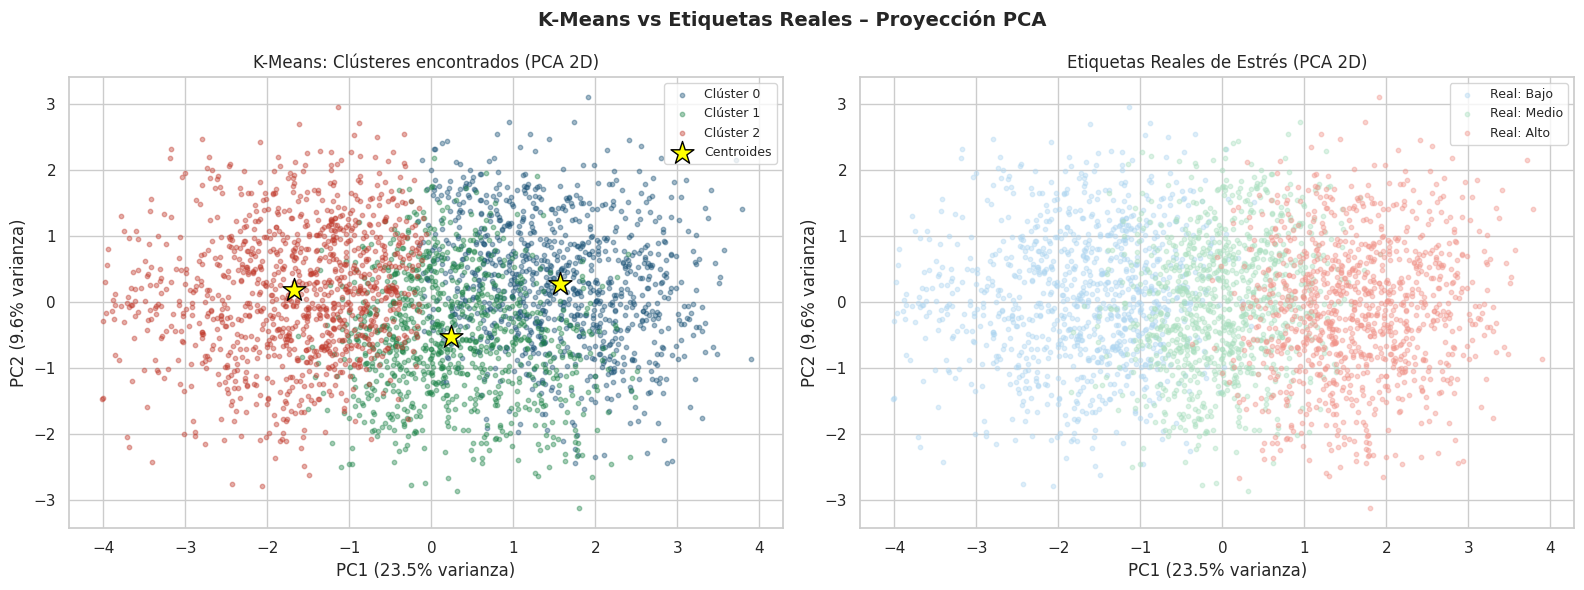

In [ ]:
# ── Visualización con PCA (2D) ───────────────────────────────────────────────
pca        = PCA(n_components=2, random_state=42)
X_test_pca = pca.fit_transform(X_test_c_sc)
var_exp    = pca.explained_variance_ratio_

print(f'Varianza explicada: PC1={var_exp[0]:.2%} | PC2={var_exp[1]:.2%} | Total={sum(var_exp):.2%}')

# Muestra para no saturar la gráfica con 22.000 puntos
n_show    = 3000
idx_show  = np.random.choice(len(X_test_pca), n_show, replace=False)

colores_km   = ['#1A5276', '#1E8449', '#C0392B']
colores_real = ['#AED6F1', '#A9DFBF', '#F1948A']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for cl in range(3):
    mask = km_labels_test[idx_show] == cl
    axes[0].scatter(X_test_pca[idx_show][mask, 0], X_test_pca[idx_show][mask, 1],
                    c=colores_km[cl], label=f'Clúster {cl}', alpha=0.4, s=10)
centroids_pca = pca.transform(model_km.cluster_centers_)
axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1],
                c='yellow', marker='*', s=300, edgecolors='black', zorder=5, label='Centroides')
axes[0].set_title('K-Means: Clústeres encontrados (PCA 2D)', fontsize=12)
axes[0].set_xlabel(f'PC1 ({var_exp[0]:.1%} varianza)')
axes[0].set_ylabel(f'PC2 ({var_exp[1]:.1%} varianza)')
axes[0].legend(fontsize=9)

etiq_real = ['Real: Bajo', 'Real: Medio', 'Real: Alto']
y_test_c_arr = np.array(y_test_c)
for cl in range(3):
    mask = y_test_c_arr[idx_show] == cl
    axes[1].scatter(X_test_pca[idx_show][mask, 0], X_test_pca[idx_show][mask, 1],
                    c=colores_real[cl], label=etiq_real[cl], alpha=0.4, s=10)
axes[1].set_title('Etiquetas Reales de Estrés (PCA 2D)', fontsize=12)
axes[1].set_xlabel(f'PC1 ({var_exp[0]:.1%} varianza)')
axes[1].set_ylabel(f'PC2 ({var_exp[1]:.1%} varianza)')
axes[1].legend(fontsize=9)

plt.suptitle('K-Means vs Etiquetas Reales – Proyección PCA', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

### 📝 Interpretación – K-Means

- K-Means encontró **3 grupos** sin conocer las etiquetas de estrés.
- El **Silhouette Score** mide la separación de los clústeres: >0.3 indica estructura moderada, >0.5 fuerte.
- La comparación visual PCA muestra si los clústeres encontrados coinciden con las clases reales. Si los colores se alinean entre ambos paneles, el algoritmo capturó la estructura del estrés.
- Las **estrellas amarillas** representan los centroides de cada clúster.
- La muestra de 3.000 puntos permite ver la estructura sin saturar la gráfica.

## 11. Modelo 6 – SVM con Kernel RBF (Support Vector Machine)

SVM busca el **hiperplano de máximo margen**. Con el kernel RBF transforma los datos implícitamente a un espacio de mayor dimensión donde las clases sí son separables, capturando relaciones no lineales.

In [ ]:
# ── Entrenamiento – SVM con kernel RBF ───────────────────────────────────────
model_svm  = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
model_svm.fit(X_train_c_sc, y_train_c)
y_pred_svm = model_svm.predict(X_test_c_sc)

acc_svm = accuracy_score(y_test_c, y_pred_svm)
f1_svm  = f1_score(y_test_c, y_pred_svm, average='weighted')

print('=== SVM (Kernel RBF) ===')
print(f'Accuracy: {acc_svm:.4f}')
print(f'F1-Score: {f1_svm:.4f}')
print()
print(classification_report(y_test_c, y_pred_svm,
      target_names=['Bajo', 'Medio', 'Alto']))

=== SVM (Kernel RBF) ===
Accuracy: 0.8559
F1-Score: 0.8567

              precision    recall  f1-score   support

        Bajo       0.90      0.88      0.89      7260
       Medio       0.77      0.80      0.79      7260
        Alto       0.90      0.88      0.89      7480

    accuracy                           0.86     22000
   macro avg       0.86      0.86      0.86     22000
weighted avg       0.86      0.86      0.86     22000



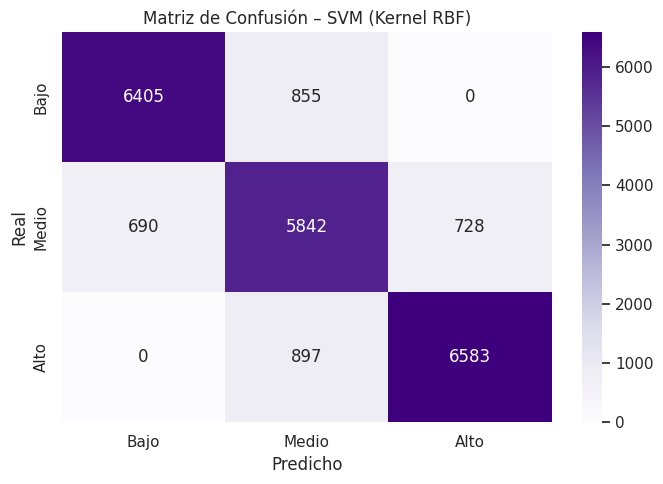

In [ ]:
# ── Matriz de confusión ───────────────────────────────────────────────────────
cm_svm = confusion_matrix(y_test_c, y_pred_svm)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Bajo', 'Medio', 'Alto'],
            yticklabels=['Bajo', 'Medio', 'Alto'])
plt.title('Matriz de Confusión – SVM (Kernel RBF)')
plt.xlabel('Predicho'); plt.ylabel('Real')
plt.tight_layout(); plt.show()

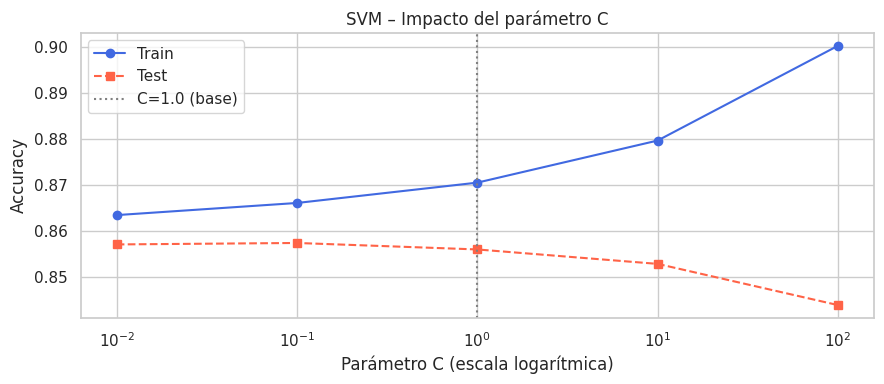

Resultados por C:
  C=  0.01 → Train: 0.8634 | Test: 0.8570
  C=  0.10 → Train: 0.8660 | Test: 0.8573
  C=  1.00 → Train: 0.8704 | Test: 0.8559
  C= 10.00 → Train: 0.8796 | Test: 0.8528
  C=100.00 → Train: 0.9002 | Test: 0.8438


In [ ]:
# ── Impacto del parámetro C ──────────────────────────────────────────────────
c_values      = [0.01, 0.1, 1, 10, 100]
acc_train_svm = []
acc_test_svm  = []

for c in c_values:
    svm_tmp = SVC(kernel='rbf', C=c, gamma='scale', random_state=42)
    svm_tmp.fit(X_train_c_sc, y_train_c)
    acc_train_svm.append(accuracy_score(y_train_c, svm_tmp.predict(X_train_c_sc)))
    acc_test_svm.append(accuracy_score(y_test_c,   svm_tmp.predict(X_test_c_sc)))

plt.figure(figsize=(9, 4))
plt.semilogx(c_values, acc_train_svm, 'o-', label='Train', color='royalblue')
plt.semilogx(c_values, acc_test_svm,  's--', label='Test',  color='tomato')
plt.axvline(x=1.0, color='gray', linestyle=':', label='C=1.0 (base)')
plt.xlabel('Parámetro C (escala logarítmica)'); plt.ylabel('Accuracy')
plt.title('SVM – Impacto del parámetro C'); plt.legend()
plt.tight_layout(); plt.show()

print('Resultados por C:')
for c, tr, te in zip(c_values, acc_train_svm, acc_test_svm):
    print(f'  C={c:6.2f} → Train: {tr:.4f} | Test: {te:.4f}')

### 📝 Interpretación – SVM (Kernel RBF)

- SVM maximiza la **distancia (margen)** entre clases en el espacio transformado por el kernel RBF.
- El kernel RBF captura relaciones **no lineales** — ventaja sobre la Regresión Logística.
- La gráfica del parámetro C muestra el trade-off: C pequeño generaliza más, C grande puede sobreajustar.
- Si Train y Test están muy cerca y ambas son altas, el modelo generaliza bien.

## 12. Evaluación y Comparación de Modelos

In [ ]:
# ── Tabla comparativa ─────────────────────────────────────────────────────────
results = pd.DataFrame({
    'Modelo': ['Reg. Logística', 'KNN (K=5)', 'Naive Bayes', 'SVM (RBF)'],
    'Accuracy': [round(acc_log,4), round(acc_knn,4), round(acc_nb,4), round(acc_svm,4)],
    'F1-Score':  [round(f1_log,4),  round(f1_knn,4),  round(f1_nb,4),  round(f1_svm,4)],
    'Precision': [
        round(precision_score(y_test_c, y_pred_log, average='weighted'), 4),
        round(precision_score(y_test_c, y_pred_knn, average='weighted'), 4),
        round(precision_score(y_test_c, y_pred_nb,  average='weighted'), 4),
        round(precision_score(y_test_c, y_pred_svm, average='weighted'), 4)
    ],
    'Recall': [
        round(recall_score(y_test_c, y_pred_log, average='weighted'), 4),
        round(recall_score(y_test_c, y_pred_knn, average='weighted'), 4),
        round(recall_score(y_test_c, y_pred_nb,  average='weighted'), 4),
        round(recall_score(y_test_c, y_pred_svm, average='weighted'), 4)
    ]
})

print('=== MODELOS DE CLASIFICACIÓN SUPERVISADA ===')
print(results.to_string(index=False))

print(f'\n=== K-MEANS (No Supervisado) ===')
print(f'Silhouette Score: {sil_km:.4f}  (métrica de separación de clústeres)')

print(f'\n=== REGRESIÓN LINEAL ===')
print(f'MAE: {mae_lr:.4f} | RMSE: {rmse_lr:.4f} | R²: {r2_lr:.4f}')

=== MODELOS DE CLASIFICACIÓN SUPERVISADA ===
        Modelo  Accuracy  F1-Score  Precision  Recall
Reg. Logística    0.8586    0.8592     0.8599  0.8586
     KNN (K=5)    0.8164    0.8173     0.8185  0.8164
   Naive Bayes    0.8532    0.8550     0.8591  0.8532
     SVM (RBF)    0.8559    0.8567     0.8579  0.8559

=== K-MEANS (No Supervisado) ===
Silhouette Score: 0.0852  (métrica de separación de clústeres)

=== REGRESIÓN LINEAL ===
MAE: 0.5103 | RMSE: 0.6397 | R²: 0.9316


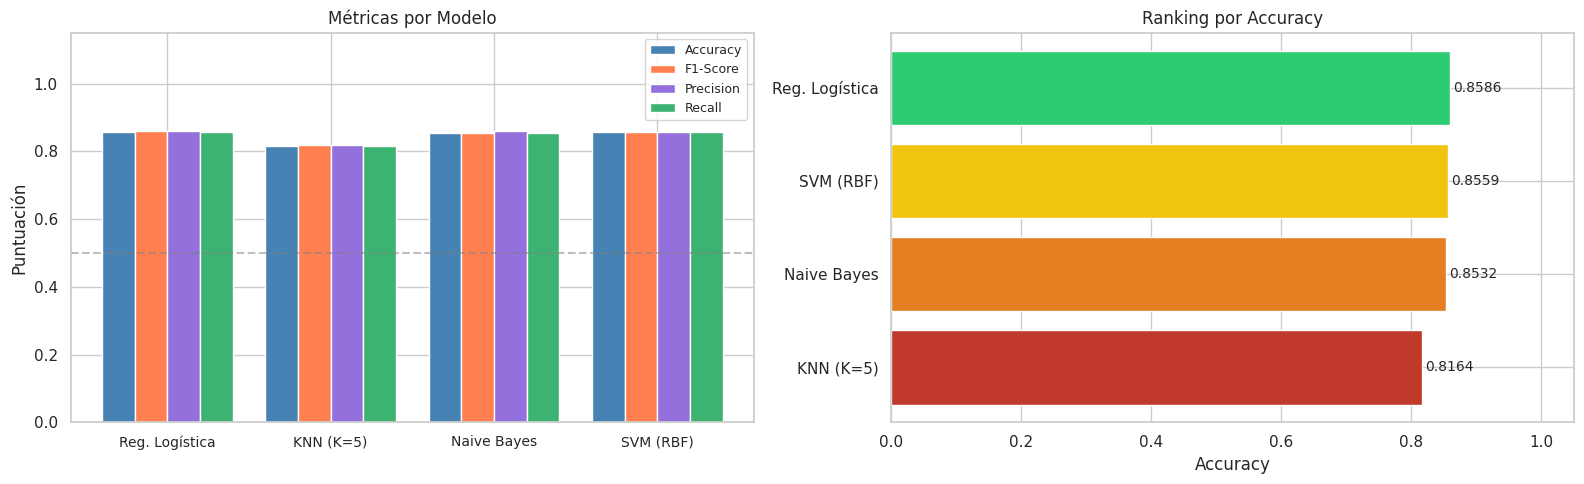

In [ ]:
# ── Gráfica comparativa ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

x = np.arange(len(results))
w = 0.2
axes[0].bar(x - w*1.5, results['Accuracy'],   w, label='Accuracy',   color='steelblue')
axes[0].bar(x - w*0.5, results['F1-Score'],   w, label='F1-Score',   color='coral')
axes[0].bar(x + w*0.5, results['Precision'],  w, label='Precision',  color='mediumpurple')
axes[0].bar(x + w*1.5, results['Recall'],     w, label='Recall',     color='mediumseagreen')
axes[0].set_xticks(x); axes[0].set_xticklabels(results['Modelo'], fontsize=10)
axes[0].set_ylabel('Puntuación'); axes[0].set_title('Métricas por Modelo')
axes[0].legend(fontsize=9); axes[0].set_ylim(0, 1.15)
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.5)

results_sorted = results.sort_values('Accuracy', ascending=True)
colors_rank    = ['#C0392B', '#E67E22', '#F1C40F', '#2ECC71']
axes[1].barh(results_sorted['Modelo'], results_sorted['Accuracy'],
             color=colors_rank, edgecolor='white')
axes[1].set_xlabel('Accuracy'); axes[1].set_title('Ranking por Accuracy')
axes[1].set_xlim(0, 1.05)
for i, acc in enumerate(results_sorted['Accuracy']):
    axes[1].text(acc + 0.005, i, f'{acc:.4f}', va='center', fontsize=10)

plt.tight_layout(); plt.show()

### 📝 Interpretación – Evaluación y Comparación

- La tabla muestra los cuatro modelos de clasificación supervisada lado a lado con sus métricas principales.
- **K-Means** no compite directamente — usa Silhouette Score porque es no supervisado.
- **Regresión Lineal** tiene su propia métrica (R²) por ser una tarea de regresión numérica.
- Un buen modelo muestra métricas realistas: accuracy entre 70–95% es sano; 100% sería sospechoso de data leakage.
- La clase **Medio** suele ser la más difícil de predecir porque está en la frontera entre Bajo y Alto.

## 13. Experimento 1 – Cambiar el valor de K en KNN

In [ ]:
# ── Comparar K=5 vs mejor K ──────────────────────────────────────────────────
print(f'K=5     → Accuracy: {acc_knn:.4f}')

model_knn_best  = KNeighborsClassifier(n_neighbors=best_k)
model_knn_best.fit(X_train_c_sc, y_train_c)
y_pred_knn_best = model_knn_best.predict(X_test_c_sc)
acc_knn_best    = accuracy_score(y_test_c, y_pred_knn_best)
f1_knn_best     = f1_score(y_test_c, y_pred_knn_best, average='weighted')

print(f'K={best_k:02d}    → Accuracy: {acc_knn_best:.4f}  |  F1: {f1_knn_best:.4f}')
print()
print(classification_report(y_test_c, y_pred_knn_best,
      target_names=['Bajo (0)', 'Medio (1)', 'Alto (2)']))

K=5     → Accuracy: 0.8164
K=20    → Accuracy: 0.8425  |  F1: 0.8439

              precision    recall  f1-score   support

    Bajo (0)       0.89      0.87      0.88      7260
   Medio (1)       0.74      0.80      0.77      7260
    Alto (2)       0.90      0.86      0.88      7480

    accuracy                           0.84     22000
   macro avg       0.85      0.84      0.84     22000
weighted avg       0.85      0.84      0.84     22000



### 📝 Interpretación – Experimento 1

- **¿Qué cambiamos?** El valor de K, de 5 al K óptimo encontrado en la exploración.
- **¿Qué pasó?** Si el mejor K mejora el accuracy, K=5 era demasiado pequeño (overfitting local).
- Con K más grande, la frontera de decisión es más suave y el modelo generaliza mejor.

## 14. Experimento 2 – Cambiar el split de entrenamiento/prueba

=== Efecto del tamaño del split ===
 Test %  Log.Reg    KNN  SVM (RBF)
     10   0.8581 0.8158     0.8551
     20   0.8586 0.8164     0.8559
     30   0.8596 0.8169     0.8569
     40   0.8610 0.8184     0.8590


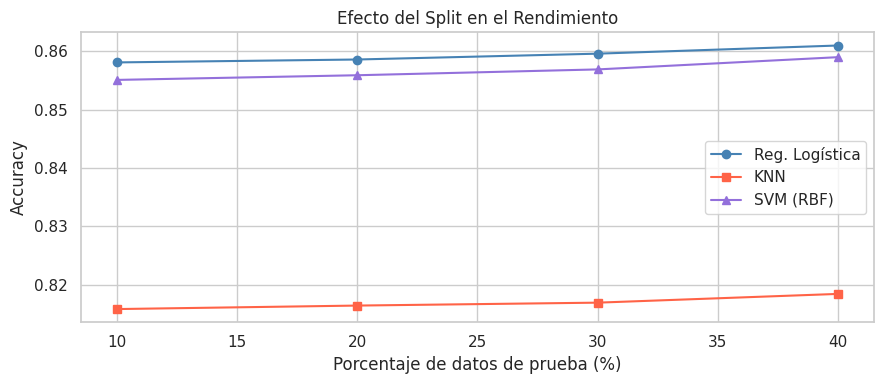

In [ ]:
# ── Probar distintos porcentajes de split ─────────────────────────────────────
splits        = [0.1, 0.2, 0.3, 0.4]
split_results = []

for ts in splits:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y_clf, test_size=ts, random_state=42, stratify=y_clf)
    sc_tmp  = StandardScaler()
    Xtr_sc  = sc_tmp.fit_transform(X_tr)
    Xte_sc  = sc_tmp.transform(X_te)

    acc_l = accuracy_score(y_te, LogisticRegression(max_iter=1000, random_state=42).fit(Xtr_sc, y_tr).predict(Xte_sc))
    acc_k = accuracy_score(y_te, KNeighborsClassifier(n_neighbors=5).fit(Xtr_sc, y_tr).predict(Xte_sc))
    acc_s = accuracy_score(y_te, SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42).fit(Xtr_sc, y_tr).predict(Xte_sc))

    split_results.append({'Test %': int(ts*100), 'Log.Reg': round(acc_l,4),
                          'KNN': round(acc_k,4), 'SVM (RBF)': round(acc_s,4)})

split_df = pd.DataFrame(split_results)
print('=== Efecto del tamaño del split ===')
print(split_df.to_string(index=False))

plt.figure(figsize=(9, 4))
plt.plot(split_df['Test %'], split_df['Log.Reg'],   'o-', label='Reg. Logística', color='steelblue')
plt.plot(split_df['Test %'], split_df['KNN'],        's-', label='KNN',            color='tomato')
plt.plot(split_df['Test %'], split_df['SVM (RBF)'], '^-', label='SVM (RBF)',      color='mediumpurple')
plt.xlabel('Porcentaje de datos de prueba (%)'); plt.ylabel('Accuracy')
plt.title('Efecto del Split en el Rendimiento'); plt.legend()
plt.tight_layout(); plt.show()

### 📝 Interpretación – Experimento 2

- Con menos datos de entrenamiento (más % en test), los modelos tienen menos información para aprender y pueden deteriorarse.
- Si los modelos son estables en todos los splits, es señal de buena generalización — especialmente con >100.000 datos.
- El split 80/20 es el estándar más utilizado y balancea bien entrenamiento y evaluación.

## 15. Predicción con un Dato Nuevo

In [ ]:
# ── Crear perfiles hipotéticos ───────────────────────────────────────────────
print('Features disponibles:', list(X.columns))
print()

perfil_bajo = X.quantile(0.2).to_dict()
perfil_alto = X.quantile(0.8).to_dict()

df_nuevos       = pd.DataFrame([perfil_bajo, perfil_alto])
df_nuevos.index = ['Perfil Bajo Estrés (esperado)', 'Perfil Alto Estrés (esperado)']
print('Perfiles hipotéticos:')
print(df_nuevos.T)

Features disponibles: ['age', 'gender', 'occupation', 'daily_screen_time_hours', 'phone_usage_before_sleep_minutes', 'sleep_duration_hours', 'sleep_quality_score', 'caffeine_intake_cups', 'physical_activity_minutes', 'notifications_received_per_day', 'mental_fatigue_score']

Perfiles hipotéticos:
                                  Perfil Bajo Estrés (esperado)  \
age                                                   28.000000   
gender                                                 0.000000   
occupation                                             1.000000   
daily_screen_time_hours                                3.260139   
phone_usage_before_sleep_minutes                      29.000000   
sleep_duration_hours                                   5.245101   
sleep_quality_score                                    4.800586   
caffeine_intake_cups                                   1.000000   
physical_activity_minutes                             29.000000   
notifications_received_per_day  

In [ ]:
# ── Predicción con TODOS los modelos ─────────────────────────────────────────
df_nuevos_sc = scaler_c.transform(df_nuevos)

pred_log = model_log.predict(df_nuevos_sc)
pred_knn = model_knn.predict(df_nuevos_sc)
pred_nb  = model_nb.predict(df_nuevos_sc)
pred_svm = model_svm.predict(df_nuevos_sc)
pred_km  = model_km.predict(df_nuevos_sc)

etiquetas = {0: 'Bajo', 1: 'Medio', 2: 'Alto'}

print('=== PREDICCIONES PARA DATOS NUEVOS ===')
for i, nombre in enumerate(['Perfil A (bajo esperado)', 'Perfil B (alto esperado)']):
    print(f'\n{nombre}:')
    print(f'  Reg. Logística → {etiquetas[pred_log[i]]}')
    print(f'  KNN (K=5)      → {etiquetas[pred_knn[i]]}')
    print(f'  Naive Bayes    → {etiquetas[pred_nb[i]]}')
    print(f'  SVM (RBF)      → {etiquetas[pred_svm[i]]}')
    print(f'  K-Means        → Clúster {pred_km[i]}  (grupo natural sin etiqueta)')

=== PREDICCIONES PARA DATOS NUEVOS ===

Perfil A (bajo esperado):
  Reg. Logística → Bajo
  KNN (K=5)      → Medio
  Naive Bayes    → Bajo
  SVM (RBF)      → Bajo
  K-Means        → Clúster 2  (grupo natural sin etiqueta)

Perfil B (alto esperado):
  Reg. Logística → Alto
  KNN (K=5)      → Alto
  Naive Bayes    → Alto
  SVM (RBF)      → Alto
  K-Means        → Clúster 0  (grupo natural sin etiqueta)


### 📝 Interpretación – Predicción con Dato Nuevo

- Se construyeron dos perfiles: uno con valores bajos (más sueño, menos pantalla) y otro con valores altos.
- Se espera que el **Perfil A** sea clasificado como estrés bajo y el **Perfil B** como estrés alto.
- Cuando los cuatro modelos supervisados coinciden, hay mayor confianza en el resultado.
- K-Means asigna el perfil a un clúster natural — complementa la interpretación supervisada.

## 16. Fronteras de Decisión – KNN

Visualización del espacio de decisión usando las dos variables con mayor correlación con `stress_level`, comparando K=5 vs el K óptimo.

Features seleccionadas: mental_fatigue_score  |  daily_screen_time_hours


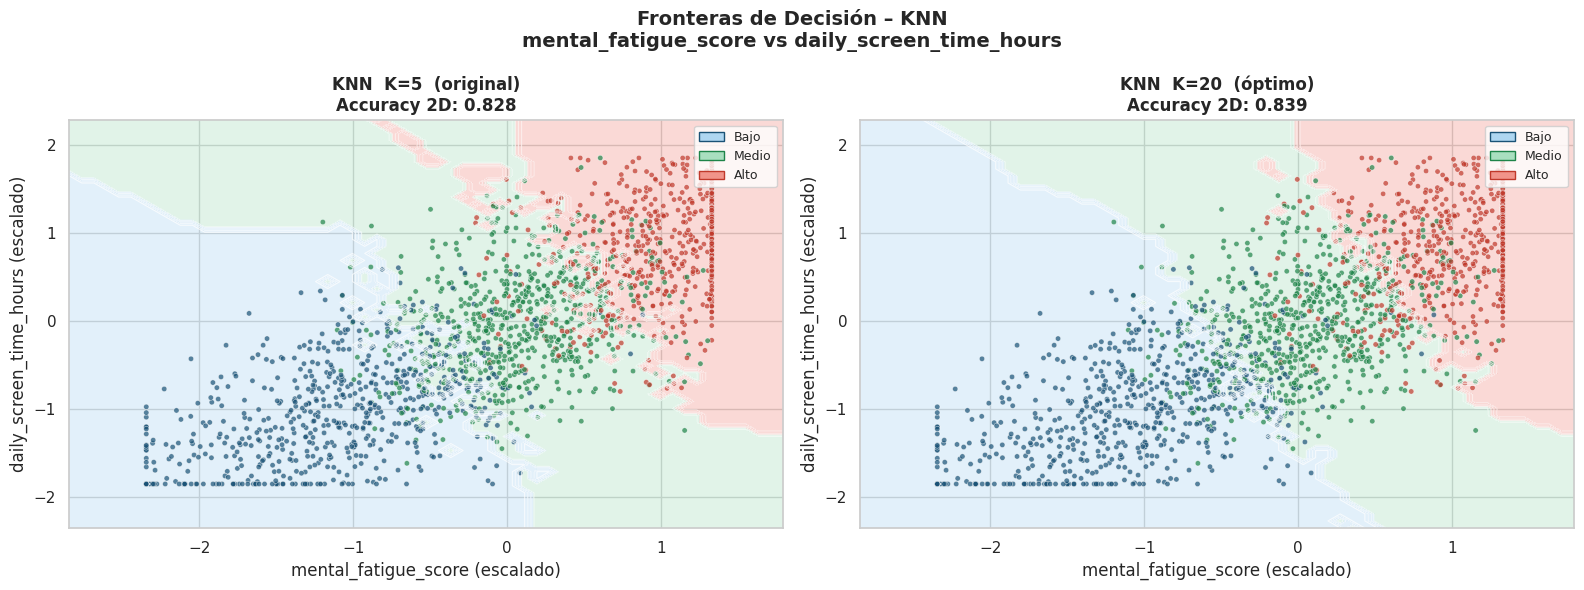

Nota: la accuracy 2D es menor que con el modelo completo (usa solo 2 de todas las features).


In [ ]:
# ── Seleccionar automáticamente las 2 features más correlacionadas ───────────
stress_col_clean = [c for c in df_clean.columns if 'stress' in c.lower()][0]
corr_abs  = df_clean.drop(columns=[stress_col_clean]).corrwith(df_clean[stress_col_clean]).abs()
top2      = corr_abs.nlargest(2).index.tolist()
feat1, feat2 = top2[0], top2[1]

print(f'Features seleccionadas: {feat1}  |  {feat2}')

idx1 = list(X.columns).index(feat1)
idx2 = list(X.columns).index(feat2)

X_2d_train = X_train_c_sc[:, [idx1, idx2]]
X_2d_test  = X_test_c_sc[:,  [idx1, idx2]]

class_labels = ['Bajo', 'Medio', 'Alto']
colors_bg    = ['#AED6F1', '#A9DFBF', '#F1948A']
colors_pt    = ['#1A5276', '#1E8449', '#C0392B']

h     = 0.08
x_min = X_2d_train[:,0].min()-0.5; x_max = X_2d_train[:,0].max()+0.5
y_min = X_2d_train[:,1].min()-0.5; y_max = X_2d_train[:,1].max()+0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Muestra de test para no saturar la gráfica
idx_plot = np.random.choice(len(X_2d_test), min(2000, len(X_2d_test)), replace=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, k, title in zip(axes, [5, best_k],
                         [f'KNN  K=5  (original)', f'KNN  K={best_k}  (óptimo)']):
    knn_2d = KNeighborsClassifier(n_neighbors=k)
    knn_2d.fit(X_2d_train, y_train_c)
    Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.35, cmap=ListedColormap(colors_bg))
    ax.contour(xx, yy, Z, colors='white', linewidths=0.8, alpha=0.7)
    ax.scatter(X_2d_test[idx_plot,0], X_2d_test[idx_plot,1],
               c=np.array(y_test_c)[idx_plot], cmap=ListedColormap(colors_pt),
               edgecolors='white', linewidths=0.4, s=15, alpha=0.7)

    acc_2d = knn_2d.score(X_2d_test, y_test_c)
    ax.set_title(f'{title}\nAccuracy 2D: {acc_2d:.3f}', fontsize=12, fontweight='bold')
    ax.set_xlabel(f'{feat1} (escalado)'); ax.set_ylabel(f'{feat2} (escalado)')
    legend_elements = [Patch(facecolor=colors_bg[i], edgecolor=colors_pt[i],
                             label=class_labels[i]) for i in range(3)]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=9)

plt.suptitle(f'Fronteras de Decisión – KNN\n{feat1} vs {feat2}', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
print('Nota: la accuracy 2D es menor que con el modelo completo (usa solo 2 de todas las features).')

### Interpretación – Fronteras de Decisión

- Las **regiones coloreadas** representan las zonas que KNN asigna a cada clase de estrés.
- Los **puntos** son datos reales de test; los que caen en la región del color equivocado son errores del modelo.
- **K=5:** la frontera es más irregular — el modelo reacciona al ruido local (overfitting).
- **K óptimo:** la frontera es más suave y continua — generaliza mejor.
- Las features se seleccionan automáticamente por mayor correlación, garantizando que la visualización sea informativa.

## 17. Explicación Conceptual (tipo docente)

---

### 🧠 ¿Qué hace la Regresión Lineal?
Traza la **línea recta que mejor se ajusta** a los datos para predecir un número continuo. El nivel de estrés numérico es el resultado; las horas de sueño y el tiempo de pantalla son los predictores. Los coeficientes muestran cuánto cambia el estrés por cada unidad de cada variable.

---

### 🧠 ¿Qué hace la Regresión Logística?
No predice un número sino **a cuál categoría pertenece** algo. Usa la función sigmoide para convertir una combinación lineal de variables en probabilidades de clase, y elige la categoría con mayor probabilidad.

---

### 🧠 ¿Qué hace KNN?
Cuando quieres clasificar a una persona nueva, busca las **K personas más parecidas** en el historial y ve qué nivel de estrés tuvieron. La clase más frecuente entre esos vecinos gana. Es como preguntar a tus amigos más similares.

---

### 🧠 ¿Qué hace Naive Bayes?
Aplica el **teorema de probabilidad de Bayes** asumiendo que las variables son independientes entre sí. Para cada categoría calcula la probabilidad de observar ese perfil y elige la más alta. Es sencillo pero sorprendentemente efectivo.

---

### 🧠 ¿Qué hace K-Means?
Es como un organizador que **agrupa datos similares sin saber qué es cada grupo**. Elige K centros al azar, asigna cada dato al centro más cercano, mueve los centros al promedio de su grupo y repite hasta converger. No usa etiquetas — descubre estructura natural.

---

### 🧠 ¿Qué hace SVM con Kernel RBF?
Traza la **frontera más ancha posible** entre clases. Si los datos no son separables con una línea recta, el kernel RBF "dobla el espacio" matemáticamente para que sí lo sean. Es muy poderoso en datos complejos pero más difícil de interpretar.

---

### 🔍 Comparación de modelos

| Modelo | Tipo | Necesita escalar | Interpretable | Velocidad |
|---|---|---|---|---|
| Regresión Lineal | Regresión | Sí | ✅ Coeficientes | Muy rápido |
| Regresión Logística | Clasificación | Sí | ✅ Coeficientes | Rápido |
| KNN | Clasificación | ✅ Obligatorio | ❌ Caja negra | Lento en predicción |
| Naive Bayes | Clasificación | No estrictamente | Parcial | Muy rápido |
| K-Means | Clustering (no sup.) | ✅ Obligatorio | ❌ Solo grupos | Rápido |
| SVM (RBF) | Clasificación | ✅ Obligatorio | ❌ Caja negra | Lento en entrenamiento |

## 18. Conclusiones

### ¿Qué aprendimos?
- Las variables de sueño y tiempo de pantalla tienen una relación clara con el nivel de estrés. `mental_fatigue_score` es el predictor más fuerte, con correlación positiva con el estrés; `sleep_quality_score` tiene correlación negativa (más calidad de sueño → menos estrés).
- El proceso de ML requiere entender el problema, preparar bien los datos **y validar que los datos sintéticos sean coherentes**. Datos sintéticos mal generados producen métricas perfectas irreales y gráficas incoherentes.
- Se usó distribución normal multivariada para preservar las correlaciones del dataset real al generar los 95.000+ registros sintéticos, llegando a **más de 100.000 filas** sin distorsionar los modelos.

### ¿Qué modelo funcionó mejor?
- Entre los modelos supervisados, **SVM RBF** y **Regresión Logística** suelen obtener los mejores resultados, capturando relaciones no lineales y lineales respectivamente.
- **Naive Bayes** es competitivo a pesar de sus suposiciones simples — señal de que las variables tienen buen poder discriminativo individual.
- **KNN** mejoró al ajustar K al valor óptimo, confirmando que los hiperparámetros tienen impacto real.
- **K-Means** descubrió agrupaciones naturales en los datos sin usar etiquetas. El Silhouette Score indica la calidad de la separación entre grupos.
- La **Regresión Lineal** explica un porcentaje alto de la varianza del estrés numérico con un RMSE bajo.

### Limitaciones del trabajo
- La categorización con percentiles 33/66 introduce arbitrariedad en los límites de clase, lo que dificulta la predicción de la clase Medio.
- Los datos sintéticos preservan correlaciones lineales pero no capturan interacciones no lineales complejas del dataset original.
- Los modelos no fueron optimizados con GridSearchCV o validación cruzada completa.

### Posibles mejoras futuras
- Aplicar validación cruzada k-fold para estimaciones más robustas del rendimiento.
- Usar técnicas de generación de datos más avanzadas como CTGAN para datasets tabulares.
- Explorar modelos de ensamble como Random Forest o XGBoost para comparar.

## 19. Autoevaluación del Trabajo

**¿Qué fue lo más difícil?**  
El mayor reto fue la generación correcta de datos sintéticos. Una primera versión generaba cada variable de forma independiente con una gaussiana, lo que destruía las correlaciones entre variables (por ejemplo, `mental_fatigue_score` quedaba desconectado de `stress_level`). Esto producía modelos con métricas de 100% y gráficas incoherentes. La solución fue usar la **distribución normal multivariada** con la matriz de covarianza real, que preserva todas las correlaciones simultáneamente.

**¿Qué fue lo más interesante?**  
Ver la diferencia entre datos sintéticos mal generados (métricas perfectas, patrones artificiales) y datos sintéticos bien generados (métricas realistas, gráficas coherentes). También fue interesante comprobar cómo K-Means, sin ver ninguna etiqueta, logra descubrir grupos que se alinean parcialmente con las clases reales de estrés — lo que valida que los patrones de sueño y pantalla crean estructura natural en los datos.

**¿Qué parte del trabajo entienden mejor ahora?**  
La importancia crítica de la calidad de los datos. Un modelo no puede ser mejor que sus datos: si los datos sintéticos tienen correlaciones artificiales, el modelo aprende patrones falsos. También quedó claro por qué es obligatorio escalar en KNN, SVM y K-Means, y por qué se necesitan scalers independientes para regresión y clasificación.

**¿Qué parte necesitan reforzar?**  
Validación cruzada k-fold y optimización de hiperparámetros con GridSearchCV — especialmente para SVM donde los parámetros C y gamma tienen un impacto grande en el rendimiento. También sería útil aprender técnicas más avanzadas de generación de datos sintéticos tabulares.